# Score with ESMIF sequences of paths

In [1]:
import os
import glob
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

## Creations of Fastas

In [2]:


def create_fasta_step(step, folder, output_filename):
    prefix = "TNLCPFGEVFNATRFA"
    
    search_pattern = os.path.join(folder, "output_*.fasta")
    files = glob.glob(search_pattern)
    
    def extract_number(filename):
        numbers = re.findall(r'\d+', os.path.basename(filename))
        return int(numbers[0]) if numbers else 0

    files.sort(key=extract_number)
    print(f"Found {len(files)} files to process.")
    
    with open(output_filename, 'w') as outfile:
        for filepath in files:
            if not os.path.isfile(filepath):
                print(f"File not found: {filepath}")
                continue
                
            with open(filepath, 'r') as infile:
                content = infile.read()
                entries = [s for s in content.split('>') if s.strip()]

                if len(entries) >= step:
                    target_entry = entries[step - 1].strip()
                    
                
                    parts = target_entry.split('\n', 1)
                    header = parts[0]
                    sequence = parts[1].replace('\n', '') if len(parts) > 1 else ""
                    
                    outfile.write(f">{header}\n{prefix}{sequence}\n")
                else:
                    print(f"Warning: {os.path.basename(filepath)} has only {len(entries)} sequences.")

    print(f"Process complete. Sequence {step} (with prefix) from each file saved to: {output_filename}")

output_filename = "esmif_paths_beta_ab_0_step_10.fasta"
create_fasta_step(10, "../paths/test_covid_T20_beta_ab_0", output_filename)

output_filename = "esmif_paths_beta_ab_0_step_21.fasta"
create_fasta_step(21, "../paths/test_covid_T20_beta_ab_0", output_filename)

output_filename = "esmif_paths_beta_ab_5_step_10.fasta"
create_fasta_step(10, "../paths/test_covid_T20_beta_ab_5", output_filename)

output_filename = "esmif_paths_beta_ab_5_step_21.fasta"
create_fasta_step(21, "../paths/test_covid_T20_beta_ab_5", output_filename)

Found 100 files to process.
Process complete. Sequence 10 (with prefix) from each file saved to: esmif_paths_beta_ab_0_step_10.fasta
Found 100 files to process.
Process complete. Sequence 21 (with prefix) from each file saved to: esmif_paths_beta_ab_0_step_21.fasta
Found 100 files to process.
Process complete. Sequence 10 (with prefix) from each file saved to: esmif_paths_beta_ab_5_step_10.fasta
Found 100 files to process.
Process complete. Sequence 21 (with prefix) from each file saved to: esmif_paths_beta_ab_5_step_21.fasta


In [3]:
def prefix_entire_fasta(input_filename, output_filename):
    prefix = "TNLCPFGEVFNATRFA"
    
    with open(input_filename, 'r') as infile, open(output_filename, 'w') as outfile:
        content = infile.read()
        entries = [e for e in content.split('>') if e.strip()]
        
        for entry in entries:
            parts = entry.strip().split('\n', 1)
            header = parts[0]
            
            sequence = parts[1].replace('\n', '').replace(' ', '') if len(parts) > 1 else ""
            
            outfile.write(f">{header}\n{prefix}{sequence}\n")

    print(f"Successfully processed all sequences.")
    print(f"New file created: {output_filename}")

prefix_entire_fasta("../gisaid/sequences_rbd_df.fasta", "esmif_rbd_df.fasta")


Successfully processed all sequences.
New file created: esmif_rbd_df.fasta


In [4]:
def prefix_entire_fasta(input_filename, output_filename):
    
    with open(input_filename, 'r') as infile, open(output_filename, 'w') as outfile:
        content = infile.read()
        entries = [e for e in content.split('>') if e.strip()]
        
        for entry in entries:
            parts = entry.strip().split('\n', 1)
            header = parts[0]
            
            sequence = parts[1].replace('\n', '').replace(' ', '') if len(parts) > 1 else ""
            
            outfile.write(f">{header}\n{sequence[2:-5]}\n")

    print(f"Successfully processed all sequences.")
    print(f"New file created: {output_filename}")

prefix_entire_fasta("../gisaid/sequences_vocs.fasta", "esmif_sequences_vocs.fasta")

Successfully processed all sequences.
New file created: esmif_sequences_vocs.fasta


# Scoring

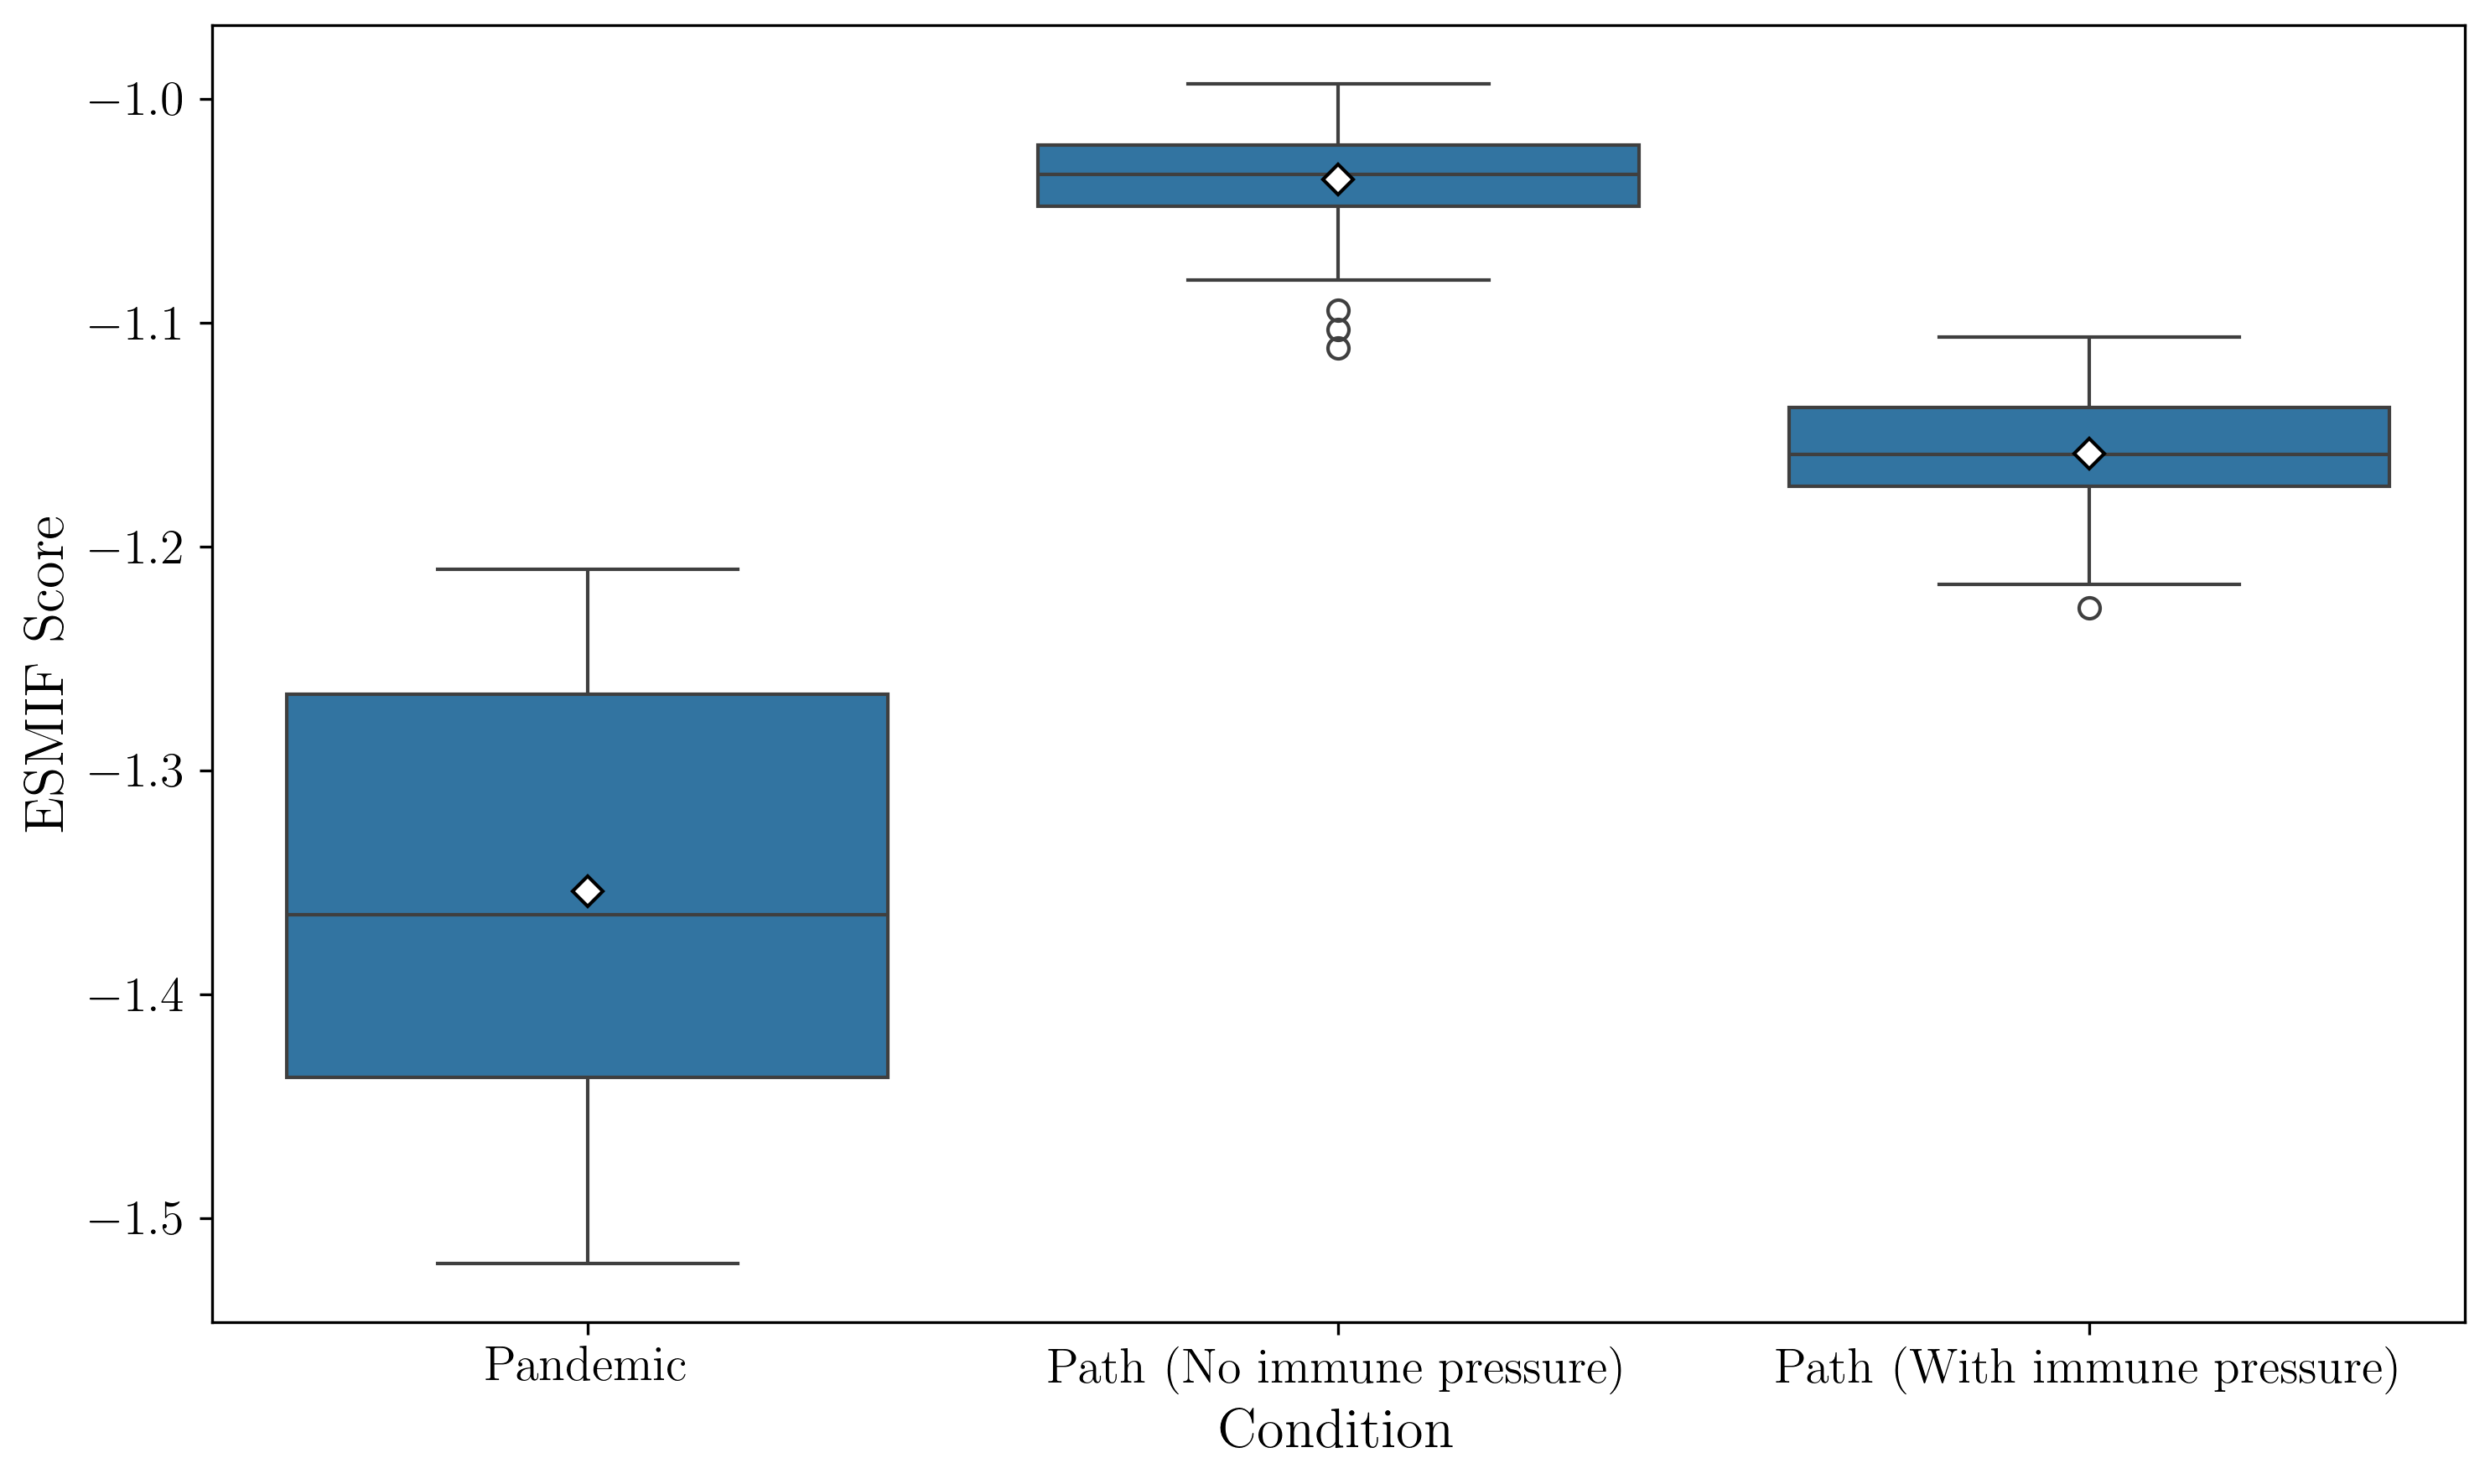

In [5]:


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"
})

def create_latex_candle_plot(output_folder=""):
    conditions = [
        {
            "file": "esmif_sequences_vocs_scores.csv", 
            "label": r"$\text{Pandemic}$", 
            "step": r"$\text{N/A}$"
        },

        {
            "file": "esmif_paths_beta_ab_0_step_21_scores.csv", 
            "label": r"$\text{Path (No immune pressure)}$", 
            "step": r"21"
        },
        {
            "file": "esmif_paths_beta_ab_5_step_21_scores.csv", 
            "label": r"$\text{Path (With immune pressure)}$",
            "step": r"21"
        }
    ]

    all_data = []
    order = []

    for cond in conditions:
        filepath = os.path.join(output_folder, cond["file"])
        if os.path.exists(filepath):
            df = pd.read_csv(filepath)
            df['Condition'] = cond["label"]
            df['Step'] = cond["step"]
            all_data.append(df)
            order.append(cond["label"])
        else:
            print(f"File not found: {filepath}")

    if not all_data:
        return

    combined_df = pd.concat(all_data, ignore_index=True)

    plt.figure(figsize=(10, 6), dpi=300)
    

    ax = sns.boxplot(
        data=combined_df, 
        x='Condition', 
        y='log_likelihood', 
        order=order,
 
        showmeans=True,
        meanprops={
            "marker": "D", 
            "markerfacecolor": "white", 
            "markeredgecolor": "black", 
            "markersize": 6
        }
    )

    # plt.title(r"$\text{ESM-IF Log-Likelihood Distribution Across Conditions}$", fontsize=16)
    plt.xlabel("Condition", fontsize=16)
    plt.ylabel(" ESMIF Score", fontsize=16)
    
    # plt.xticks(rotation=15)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    # plt.legend(title=r"$\text{Step}$", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    create_latex_candle_plot()